#Librerias

In [145]:
import pandas as pd
import numpy as np
import os
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Cargamos el dataset

In [146]:
#Definir los dataframes
df1, meta1= pyreadstat.read_sav(os.getcwd()+'/dataCP.sav')
df2, meta2= pyreadstat.read_sav(os.getcwd()+'/dataO.sav')

#Limpieza y transformación de los datos

In [148]:
#Seleccionamos las variables con las que trabajaremos
df1= df1[['DIRECTORIO','SECUENCIA_P','ORDEN','DPTO', 'POB_MAY18','P6040','P3271','P3042','FEX_C18',]]
df2= df2[['DIRECTORIO','SECUENCIA_P','ORDEN','P6430','P6940','INGLABO','RAMA2D_R4']]

#Definimos el tipo de datos de cada variable
df1['DIRECTORIO'] = df1['DIRECTORIO'].astype('int')
df1['SECUENCIA_P'] = df1['SECUENCIA_P'].astype('int')
df1['ORDEN'] = df1['ORDEN'].astype('int')
df1["FEX_C18"] = df1["FEX_C18"].astype(float)
df2['DIRECTORIO'] = df2['DIRECTORIO'].astype('int')
df2['SECUENCIA_P'] = df2['SECUENCIA_P'].astype('int')
df2['ORDEN'] = df2['ORDEN'].astype('int')

#Filtramos los datos
df1 = df1[df1['POB_MAY18'] == 1] #Mayores de edad
df2 = df2[df2['P6430']==1] #Personas empleadas dependientes
df2 = df2[df2['P6940']==1] #Empleos formales
df2 = df2.dropna(subset=['INGLABO']) #Eliminamos salarios nulos



#Recategorizamos etiquetas
df1.loc[(df1['P6040']<26),'P6040']=1
df1.loc[(df1['P6040']>25) & (df1['P6040']<31),'P6040']=2
df1.loc[(df1['P6040']>30) & (df1['P6040']<36),'P6040']=3
df1.loc[(df1['P6040']>35) & (df1['P6040']<41),'P6040']=4
df1.loc[(df1['P6040']>40),'P6040']=5 #Rangos de edad

df1.loc[(df1['P3271']==2),'P3271']=0 #cambio de sexo

df2.loc[(df2['RAMA2D_R4'] < 4), 'RAMA2D_R4'] = 1
df2.loc[(df2['RAMA2D_R4'] > 4) & (df2['RAMA2D_R4'] < 9), 'RAMA2D_R4'] = 2
df2.loc[(df2['RAMA2D_R4'] > 9) & (df2['RAMA2D_R4'] < 34), 'RAMA2D_R4'] = 3
df2.loc[(df2['RAMA2D_R4'] == 35), 'RAMA2D_R4'] = 4
df2.loc[(df2['RAMA2D_R4'] > 35) & (df2['RAMA2D_R4'] < 40), 'RAMA2D_R4'] = 5
df2.loc[(df2['RAMA2D_R4'] > 40) & (df2['RAMA2D_R4'] < 44), 'RAMA2D_R4'] = 6
df2.loc[(df2['RAMA2D_R4'] > 44) & (df2['RAMA2D_R4'] < 48), 'RAMA2D_R4'] = 7
df2.loc[(df2['RAMA2D_R4'] > 48) & (df2['RAMA2D_R4'] < 54), 'RAMA2D_R4'] = 8
df2.loc[(df2['RAMA2D_R4'] > 54) & (df2['RAMA2D_R4'] < 57), 'RAMA2D_R4'] = 9
df2.loc[(df2['RAMA2D_R4'] > 57) & (df2['RAMA2D_R4'] < 64), 'RAMA2D_R4'] = 10
df2.loc[(df2['RAMA2D_R4'] > 63) & (df2['RAMA2D_R4'] < 67), 'RAMA2D_R4'] = 11
df2.loc[(df2['RAMA2D_R4'] == 68), 'RAMA2D_R4'] = 12
df2.loc[(df2['RAMA2D_R4'] > 68) & (df2['RAMA2D_R4'] < 76), 'RAMA2D_R4'] = 13
df2.loc[(df2['RAMA2D_R4'] > 76) & (df2['RAMA2D_R4'] < 83), 'RAMA2D_R4'] = 14
df2.loc[(df2['RAMA2D_R4'] == 84), 'RAMA2D_R4'] = 15
df2.loc[(df2['RAMA2D_R4'] == 85), 'RAMA2D_R4'] = 16
df2.loc[(df2['RAMA2D_R4'] > 85) & (df2['RAMA2D_R4'] < 89), 'RAMA2D_R4'] = 17
df2.loc[(df2['RAMA2D_R4'] > 89) & (df2['RAMA2D_R4'] < 94), 'RAMA2D_R4'] = 18
df2.loc[(df2['RAMA2D_R4'] > 93) & (df2['RAMA2D_R4'] < 97), 'RAMA2D_R4'] = 19
df2.loc[(df2['RAMA2D_R4'] > 96) & (df2['RAMA2D_R4'] < 99), 'RAMA2D_R4'] = 20
df2.loc[df2['RAMA2D_R4'] == 99, 'RAMA2D_R4'] = 21  #Sectores economicos

df1.loc[(df1['P3042']==1),'P3042']=0
df1.loc[(df1['P3042']==2),'P3042']=1
df1.loc[(df1['P3042']==3),'P3042']=1
df1.loc[(df1['P3042']==4),'P3042']=2
df1.loc[(df1['P3042']==5),'P3042']=3
df1.loc[(df1['P3042']==6),'P3042']=3
df1.loc[(df1['P3042']==7),'P3042']=3
df1.loc[(df1['P3042']==8),'P3042']=4
df1.loc[(df1['P3042']==9),'P3042']=5
df1.loc[(df1['P3042']==10),'P3042']=6
df1.loc[(df1['P3042']==11),'P3042']=7
df1.loc[(df1['P3042']==12),'P3042']=7
df1.loc[(df1['P3042']==13),'P3042']=7 #Nivel educativo

#Creamos las llaves para unir la tabla de caracteristicas de las personas con la tabla de situación laboral
df1['UID'] = df1['DIRECTORIO'].astype(str) + "-" + \
             df1['SECUENCIA_P'].astype(str) + "-" + \
             df1['ORDEN'].astype(str)
df1.set_index('UID', inplace=True)

df2['UID'] = df2['DIRECTORIO'].astype(str) + "-" + \
             df2['SECUENCIA_P'].astype(str) + "-" + \
             df2['ORDEN'].astype(str)
df2.set_index('UID', inplace=True)

#Unimos las tablas en un unico dataframe
testMerge = pd.merge(df1, df2, left_index=True, right_index=True)
testMerge['FEX_C18'] = (testMerge['FEX_C18'].round()/50).astype(int)
dfFinal = testMerge.loc[testMerge.index.repeat(testMerge['FEX_C18'])].copy()
dfFinal.shape
dfFinal.drop(["DIRECTORIO_x","SECUENCIA_P_x","ORDEN_x","DIRECTORIO_y","SECUENCIA_P_y","ORDEN_y","FEX_C18","P6430","P6940","POB_MAY18","DPTO"], axis=1, inplace=True)
df=dfFinal.copy()

#Renombramos las columnas
df = df.rename(columns={'P6040': 'edad', 'P3271': 'sexo','P3042':'neducativo','INGLABO':'salario','RAMA2D_R4':'sector'})


#Exploración del dataset

In [149]:
print(df.shape)
df.head(5) #Estructura del DF

(302534, 5)


,edad,sexo,neducativo,salario,sector
UID,,,,,
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302534 entries, 7655976-1-2 to 8086861-1-2
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   edad        302534 non-null  float64
 1   sexo        302534 non-null  float64
 2   neducativo  302534 non-null  float64
 3   salario     302534 non-null  float64
 4   sector      302534 non-null  float64
dtypes: float64(5)
memory usage: 13.8+ MB


In [151]:
df.describe()

,edad,sexo,neducativo,salario,sector
count,302534.000000,302534.000000,302534.000000,3.025340e+05,302534.000000
mean,3.324205,0.569972,3.960510,2.371743e+06,8.446257
std,1.503555,0.495080,1.652199,2.765657e+06,4.923542
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000
25%,2.000000,0.000000,3.000000,1.300000e+06,3.000000
50%,3.000000,1.000000,3.000000,1.500000e+06,7.000000
75%,5.000000,1.000000,6.000000,2.202000e+06,12.000000
max,5.000000,1.000000,7.000000,8.745000e+07,21.000000


In [152]:
df.isnull().sum() #Verificacion de valores no nulos

edad          0
sexo          0
neducativo    0
salario       0
sector        0
dtype: int64

In [153]:
df.nunique() #verificación de niveles en cada variable

edad            5
sexo            2
neducativo      8
salario       661
sector         20
dtype: int64

In [177]:
df.to_csv('df_limpio.csv')

#Análisis univariado y multivariado




Group 0.0 (n=130098):
  - Outlier boundaries: -1,700,000.00 to 5,300,000.00
  - Identified 7488 extreme outliers (5.76%)
Group 1.0 (n=172436):
  - Outlier boundaries: -1,400,000.00 to 4,900,000.00
  - Identified 14609 extreme outliers (8.47%)

Removed total of 22097 extreme outliers
Original size: 302534, New size: 280437


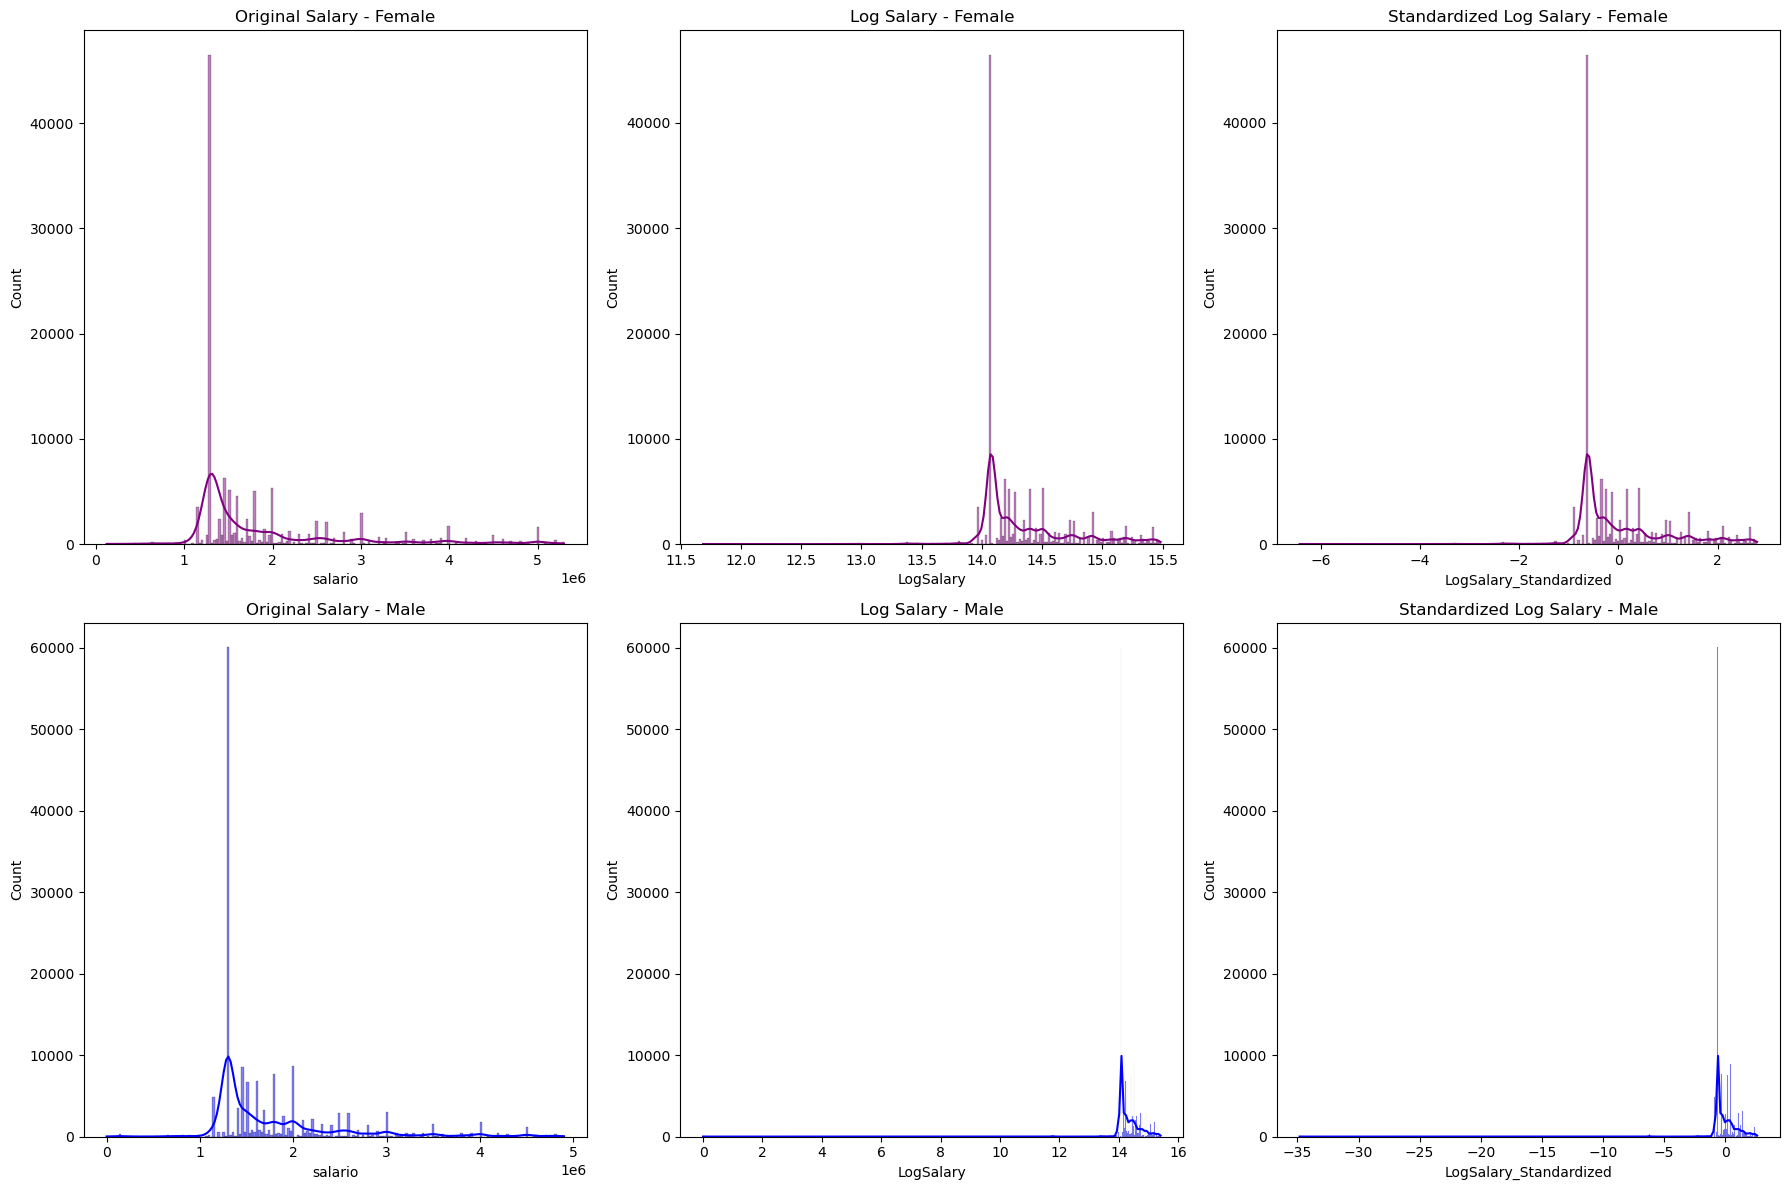


Summary of normalized variables:

salario:
count    2.804370e+05
mean     1.813674e+06
std      8.189748e+05
min      0.000000e+00
25%      1.300000e+06
50%      1.462000e+06
75%      2.000000e+06
max      5.300000e+06
Name: salario, dtype: float64

LogSalary:
count    280437.000000
mean         14.331876
std           0.411626
min           0.000000
25%          14.077876
50%          14.195317
75%          14.508658
max          15.483218
Name: LogSalary, dtype: float64

Salary_MinMax:
count    280437.000000
mean          0.342203
std           0.154524
min           0.000000
25%           0.245283
50%           0.275849
75%           0.377358
max           1.000000
Name: Salary_MinMax, dtype: float64

LogSalary_MinMax:
count    280437.000000
mean          0.925639
std           0.026585
min           0.000000
25%           0.909235
50%           0.916820
75%           0.937057
max           1.000000
Name: LogSalary_MinMax, dtype: float64

Salary_Standardized:
count    2.804370e+05


In [160]:
def remove_extreme_outliers(df, column='salario', group_col='sexo', threshold=3):
    """
    Se deben eliminar datos anómalos extremos que causan un desequilibro entre las features y el target (salarios muy altos).
    En este caso, lo hacemos agrupándolos por sexo, eliminando datos anómalos de la columna 'salario'
    """
    df_clean = df.copy()
    outlier_indices = []
    
    for group in df[group_col].unique():
        group_data = df[df[group_col] == group][column]
        
        # Cuartiles por fuera de los cuales se eliminan
        Q1 = group_data.quantile(0.25)
        Q3 = group_data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Fronteras de decisión
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        # Indice de los elementos fuera
        outliers = df[(df[group_col] == group) & 
                      ((df[column] < lower_bound) | (df[column] > upper_bound))].index
        
        outlier_indices.extend(outliers)
        
        print(f"Grupo {group} (n={len(group_data)}):")
        print(f"  - Fronteras de anómalos: {lower_bound:,.2f} to {upper_bound:,.2f}")
        print(f"  - Se identificaron {len(outliers)} datos anómalos extremos ({len(outliers)/len(group_data)*100:.2f}%)")
    
    # Create clean dataframe without outliers
    df_clean = df_clean.drop(outlier_indices)
    print(f"\n Se eliminaron {len(outlier_indices)} outliers")
    print(f"Tamaño inicial: {len(df)}, Nuevo tamaño: {len(df_clean)}")
    
    return df_clean

df_clean = remove_extreme_outliers(df, column='salario', group_col='sexo', threshold=3)

# Now let's normalize the salary using two methods
# 1. Min-Max scaling (values between 0 and 1)
# 2. Standardization (mean=0, std=1)

# Create original log-transformed salary
df_clean['LogSalary'] = np.log1p(df_clean['salario'])

# Min-Max scaling
mm_scaler = MinMaxScaler()
df_clean['Salary_MinMax'] = mm_scaler.fit_transform(df_clean[['salario']])
df_clean['LogSalary_MinMax'] = mm_scaler.fit_transform(df_clean[['LogSalary']])

# Standardization (Z-score)
std_scaler = StandardScaler()
df_clean['Salary_Standardized'] = std_scaler.fit_transform(df_clean[['salario']])
df_clean['LogSalary_Standardized'] = std_scaler.fit_transform(df_clean[['LogSalary']])

# Let's visualize the results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original salary distribution after outlier removal
for i, gender in enumerate([0, 1]):
    gender_label = 'Female' if gender == 0 else 'Male'
    gender_data = df_clean[df_clean['sexo'] == gender]
    
    # Original salary (no transformation)
    sns.histplot(data=gender_data, x='salario', kde=True, 
                 color='purple' if gender == 0 else 'blue', ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Salary - {gender_label}')
    
    # Log-transformed salary
    sns.histplot(data=gender_data, x='LogSalary', kde=True, 
                 color='purple' if gender == 0 else 'blue', ax=axes[i, 1])
    axes[i, 1].set_title(f'Log Salary - {gender_label}')
    
    # Standardized log-salary
    sns.histplot(data=gender_data, x='LogSalary_Standardized', kde=True, 
                 color='purple' if gender == 0 else 'blue', ax=axes[i, 2])
    axes[i, 2].set_title(f'Standardized Log Salary - {gender_label}')

plt.tight_layout()
plt.show()

# Print summary of transformed variables
print("\nSummary of normalized variables:")
for col in ['salario', 'LogSalary', 'Salary_MinMax', 'LogSalary_MinMax', 
           'Salary_Standardized', 'LogSalary_Standardized']:
    print(f"\n{col}:")
    print(df_clean[col].describe())

In [157]:
df_clean.head()

,edad,sexo,neducativo,salario,sector,LogSalary,Salary_MinMax,LogSalary_MinMax,Salary_Standardized,LogSalary_Standardized
UID,,,,,,,,,,
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388


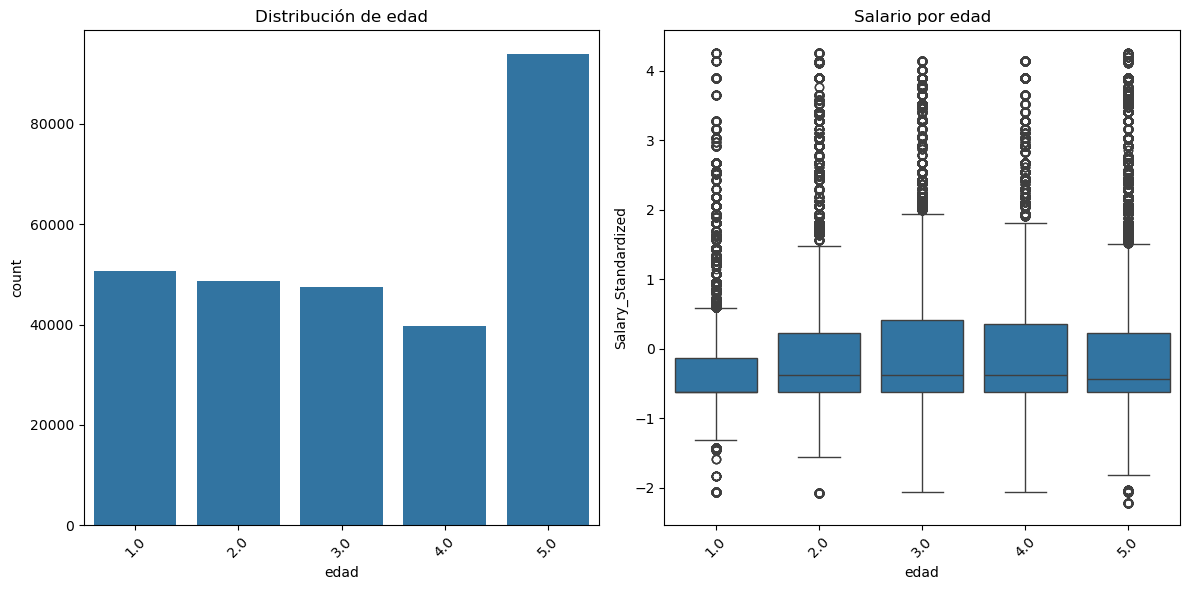

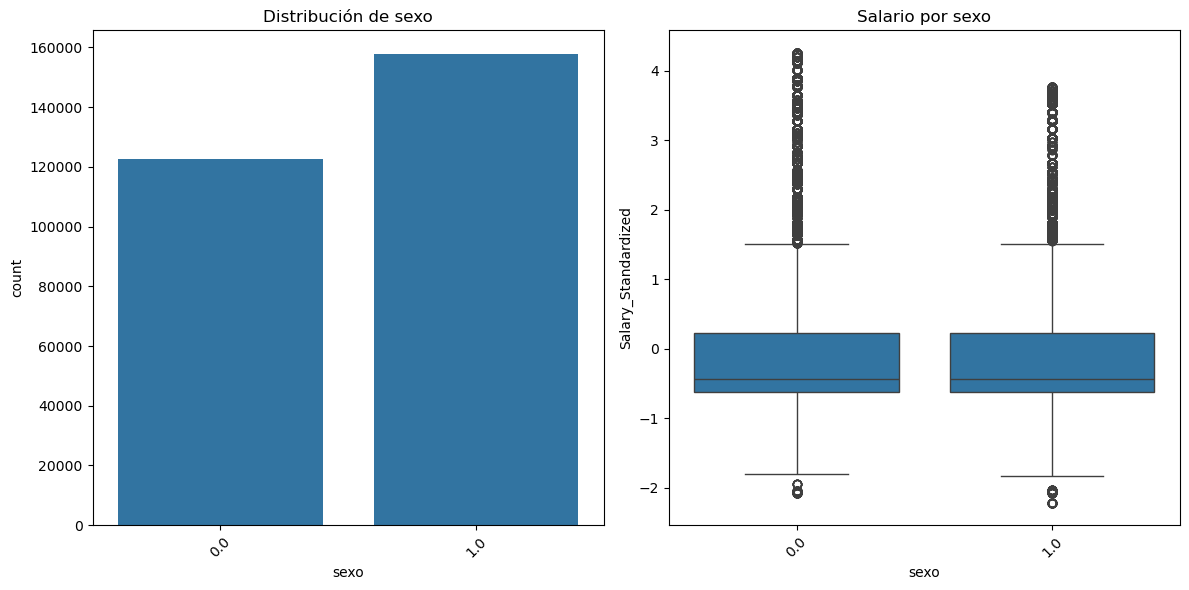

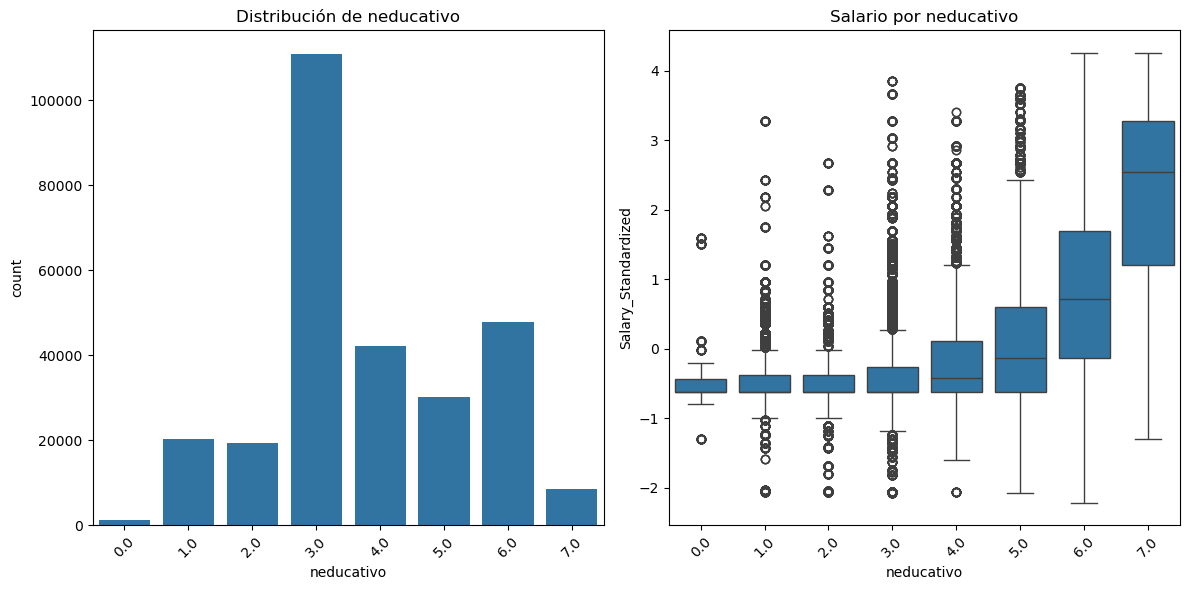

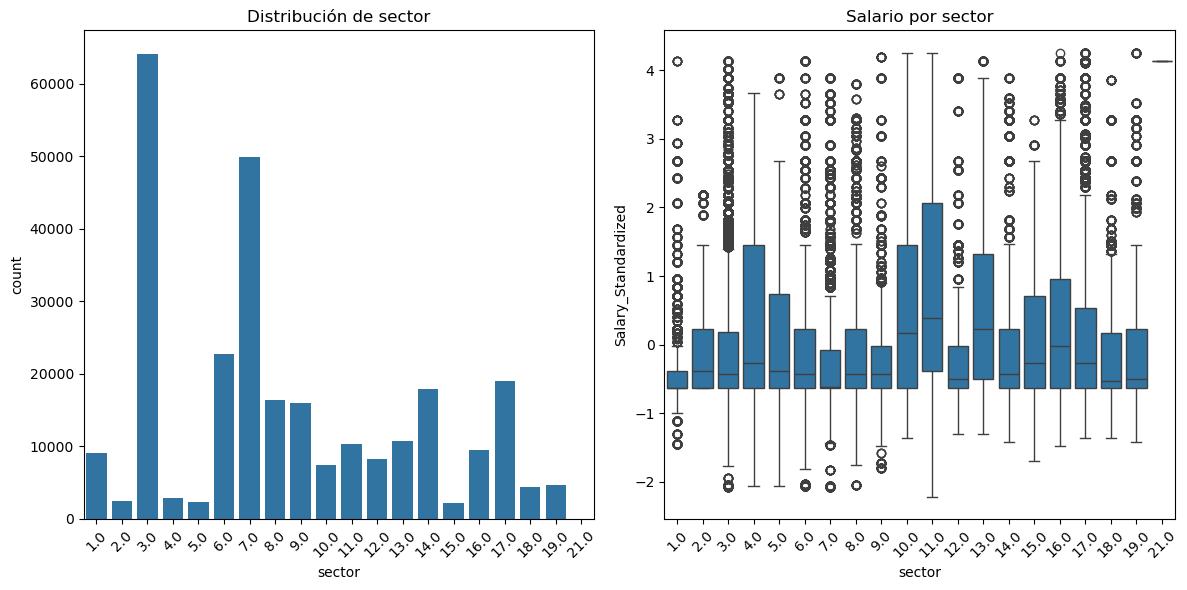

In [102]:
for cat_var in ['edad', 'sexo', 'neducativo', 'sector']:
    plt.figure(figsize=(12, 6))
    
    # Distribution
    plt.subplot(1, 2, 1)
    sns.countplot(x=cat_var, data=df_clean)
    plt.title(f'Distribución de {cat_var}')
    plt.xticks(rotation=45)
    
    # Relationship with target
    plt.subplot(1, 2, 2)
    sns.boxplot(x=cat_var, y='Salary_Standardized', data=df_clean)
    plt.title(f'Salario por {cat_var}')
    plt.xticks(rotation=45)
    plt.tight_layout()

G:\Programs\Anaconda\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


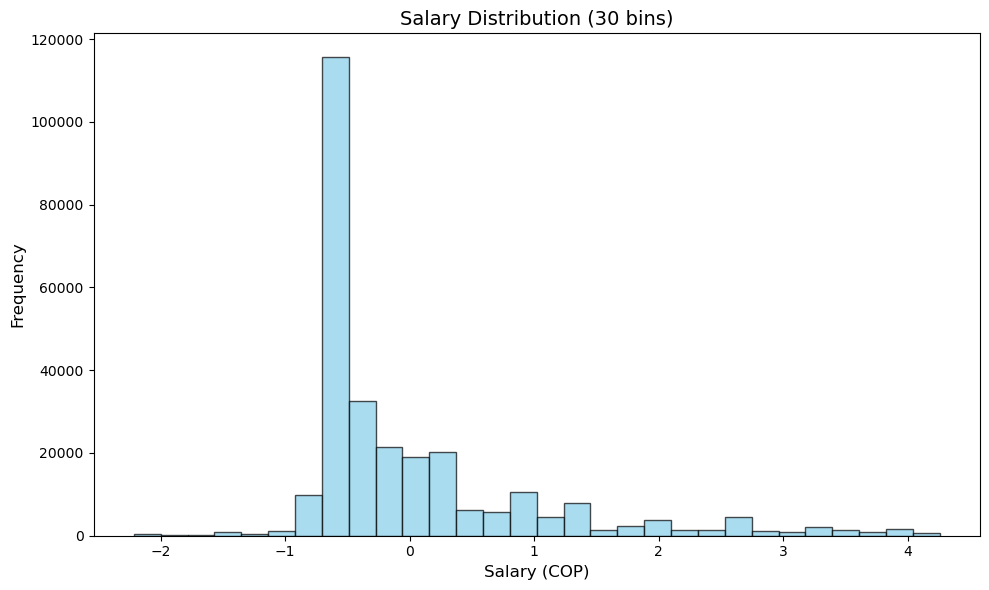

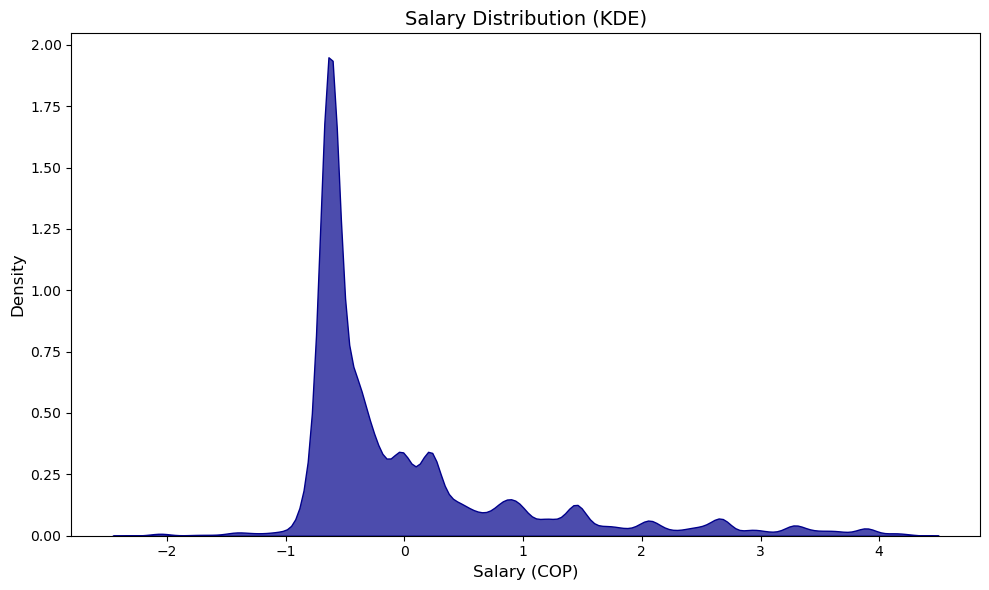

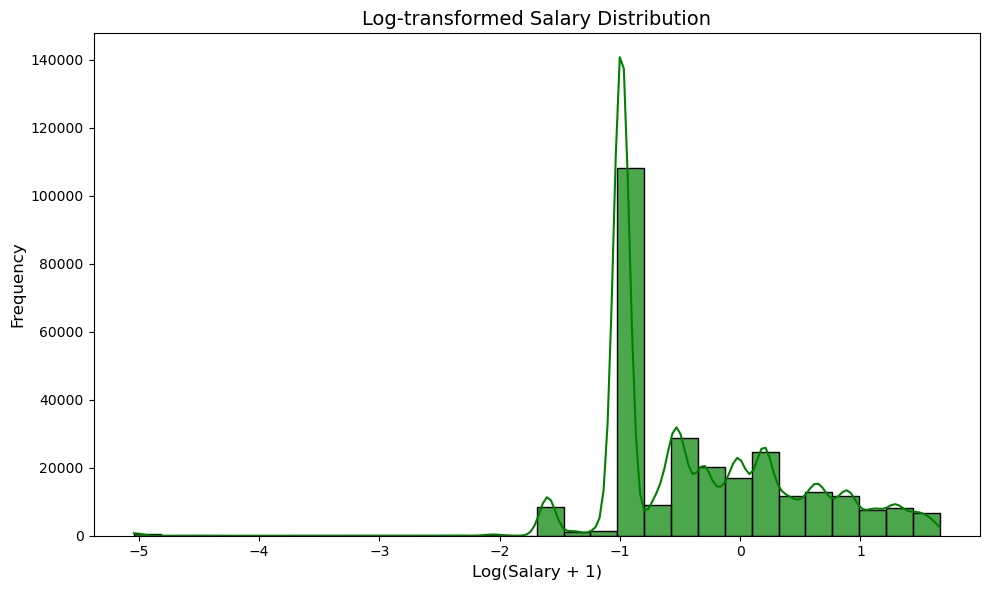

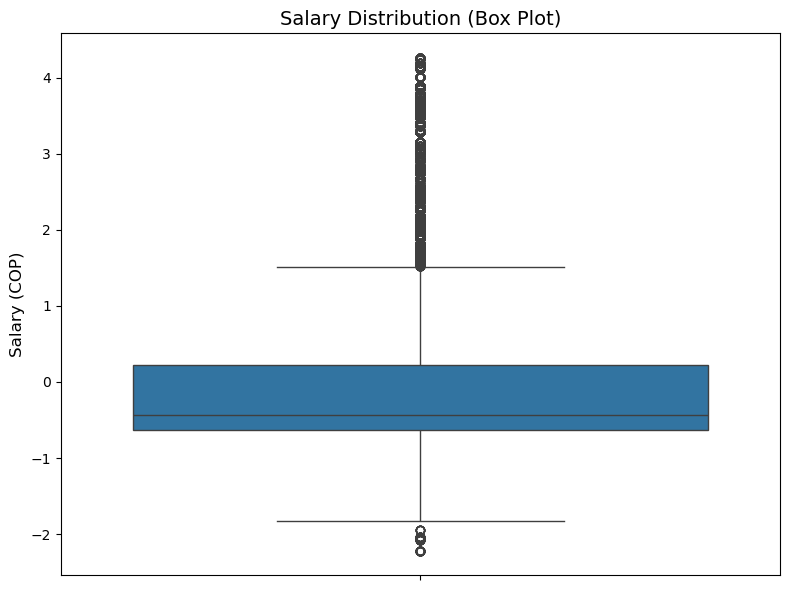

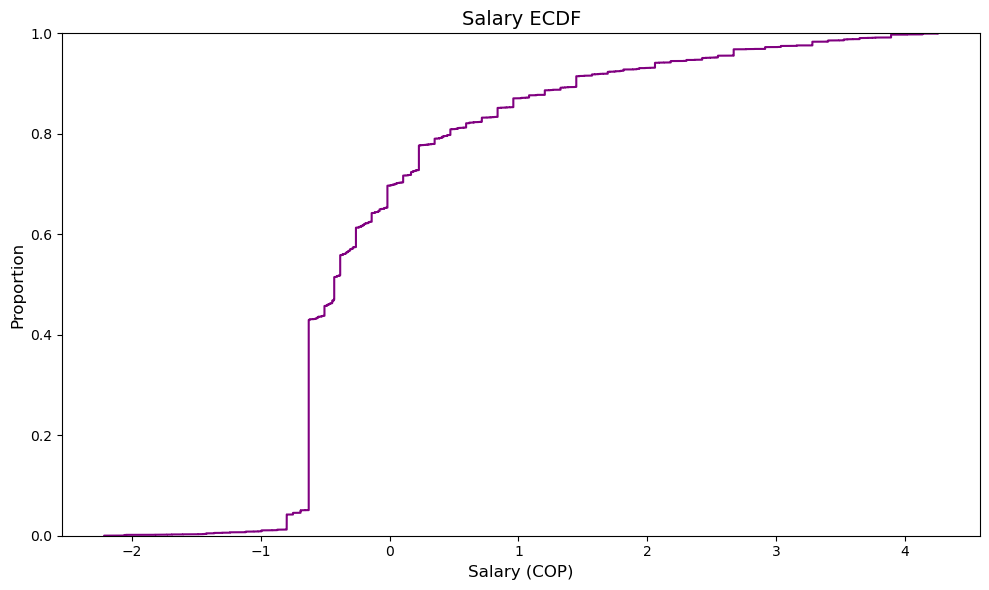

In [103]:

# 1. Histogram with appropriate bins
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Salary_Standardized'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Salary Distribution (30 bins)', fontsize=14)
plt.xlabel('Salary (COP)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')  # Prevent scientific notation
plt.tight_layout()

# 2. Kernel Density Estimation (KDE) plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean['Salary_Standardized'], fill=True, color='darkblue', alpha=0.7)
plt.title('Salary Distribution (KDE)', fontsize=14)
plt.xlabel('Salary (COP)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()

# 3. Log-transformed salary (often better for salary data)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df_clean['Salary_Standardized']), kde=True, bins=30, color='green', alpha=0.7)
plt.title('Log-transformed Salary Distribution', fontsize=14)
plt.xlabel('Log(Salary + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()

# 4. Box plot to see outliers and quartiles
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean['Salary_Standardized'])
plt.title('Salary Distribution (Box Plot)', fontsize=14)
plt.ylabel('Salary (COP)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

# 5. ECDF (Empirical Cumulative Distribution Function)
plt.figure(figsize=(10, 6))
sns.ecdfplot(df_clean['Salary_Standardized'], color='purple')
plt.title('Salary ECDF', fontsize=14)
plt.xlabel('Salary (COP)', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()

In [56]:
import pandas as pd
import numpy as np

def analyze_outliers_by_age():
    outlier_stats = {}
    
    for age in sorted(df['edad'].unique()):
        # Filter data for this age group
        age_data = df[df['edad'] == age]['salario']
        
        # Calculate quartiles
        Q1 = age_data.quantile(0.25)
        Q3 = age_data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outliers
        outliers = age_data[(age_data < lower_bound) | (age_data > upper_bound)]
        
        # Calculate percentage
        outlier_percentage = (len(outliers) / len(age_data)) * 100
        
        # Store results
        outlier_stats[age] = {
            'total_count': len(age_data),
            'outlier_count': len(outliers),
            'outlier_percentage': outlier_percentage,
            'min_salary': age_data.min(),
            'max_salary': age_data.max(),
            'median_salary': age_data.median(),
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
    
    return outlier_stats

# Get the outlier statistics
outlier_stats = analyze_outliers_by_age()

# Create a formatted print output
print("\n===== OUTLIER ANALYSIS BY AGE GROUP =====\n")
for age, stats in outlier_stats.items():
    print(f"Age Group: {age}")
    print(f"Total samples: {stats['total_count']:,}")
    print(f"Outlier count: {stats['outlier_count']:,} ({stats['outlier_percentage']:.2f}%)")
    print(f"Salary range: {stats['min_salary']:,.0f} to {stats['max_salary']:,.0f} COP")
    print(f"IQR boundaries: {stats['lower_bound']:,.0f} to {stats['upper_bound']:,.0f} COP")
    print(f"Median salary: {stats['median_salary']:,.0f} COP")
    print("-" * 50)

# Create a summary dataframe for easier comparison
summary_df = pd.DataFrame({
    'Age Group': list(outlier_stats.keys()),
    'Total Count': [stats['total_count'] for stats in outlier_stats.values()],
    'Outliers': [stats['outlier_count'] for stats in outlier_stats.values()],
    'Outlier %': [stats['outlier_percentage'] for stats in outlier_stats.values()],
    'Median Salary': [stats['median_salary'] for stats in outlier_stats.values()]
})

print("\n===== SUMMARY TABLE =====\n")
print(summary_df.to_string(index=False))


===== OUTLIER ANALYSIS BY AGE GROUP =====

Age Group: 1.0
Total samples: 51,086
Outlier count: 5,286 (10.35%)
Salary range: 130,000 to 13,000,000 COP
IQR boundaries: 625,000 to 2,425,000 COP
Median salary: 1,300,000 COP
--------------------------------------------------
Age Group: 2.0
Total samples: 51,683
Outlier count: 5,899 (11.41%)
Salary range: 116,000 to 67,000,000 COP
IQR boundaries: -200,000 to 3,800,000 COP
Median salary: 1,574,000 COP
--------------------------------------------------
Age Group: 3.0
Total samples: 51,709
Outlier count: 5,431 (10.50%)
Salary range: 130,000 to 38,000,000 COP
IQR boundaries: -635,000 to 4,525,000 COP
Median salary: 1,600,000 COP
--------------------------------------------------
Age Group: 4.0
Total samples: 44,174
Outlier count: 3,847 (8.71%)
Salary range: 130,000 to 87,450,000 COP
IQR boundaries: -950,000 to 5,050,000 COP
Median salary: 1,600,000 COP
--------------------------------------------------
Age Group: 5.0
Total samples: 103,882
Outl

In [ ]:
edad	sexo	neducativo	salario	sector	LogSalary	Salary_MinMax	LogSalary_MinMax	Salary_Standardized	LogSalary_Standardized

Index(['edad', 'sexo', 'neducativo', 'salario', 'sector', 'LogSalary',
       'Salary_MinMax', 'LogSalary_MinMax', 'Salary_Standardized',
       'LogSalary_Standardized'],
      dtype='object')


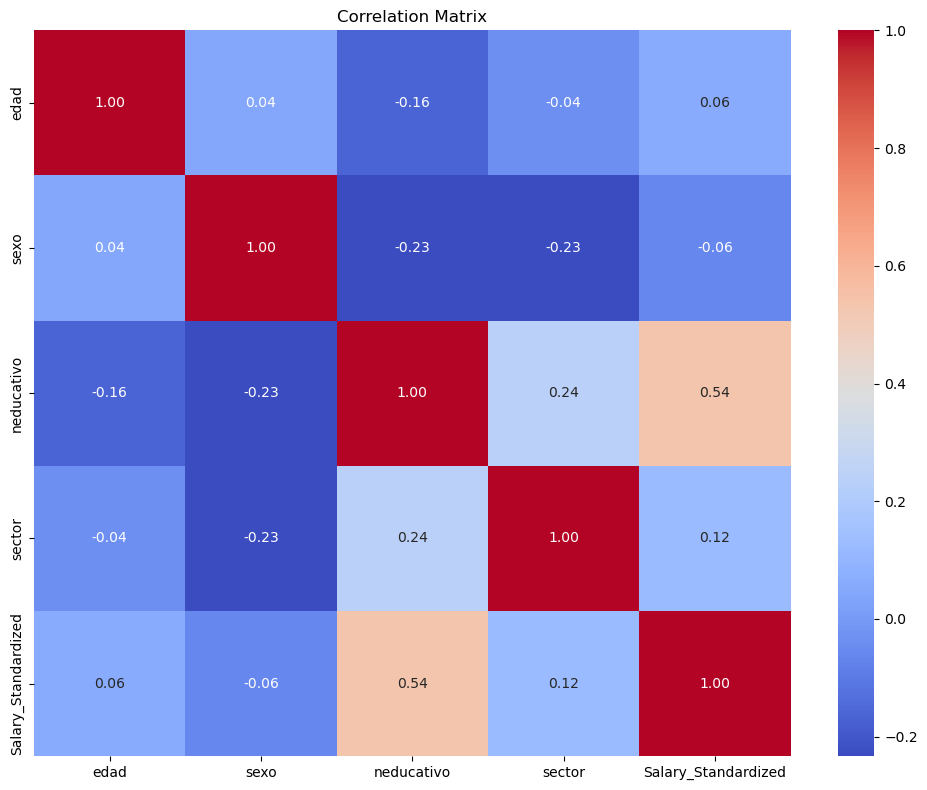

In [162]:
print(df_clean.columns)
plt.figure(figsize=(10, 8))
numeric_df = df_clean.drop(["LogSalary", "Salary_MinMax", "LogSalary_MinMax", "salario","LogSalary_Standardized"], axis=1).select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

In [105]:
# Create interaction terms
df_clean['edu_age_interaction'] = df_clean['neducativo'] * df_clean['edad']
df_clean['edu_sector_interaction'] = df_clean['neducativo'] * df_clean['sector']

# Create binned/grouped features for sector


# Group similar sectors by average salary
sector_salary = df_clean.groupby('sector')['Salary_Standardized'].mean().reset_index()
scaler = StandardScaler()
sector_salary_scaled = scaler.fit_transform(sector_salary[['Salary_Standardized']])

# Use KMeans to group sectors into 4-5 salary tiers
kmeans = KMeans(n_clusters=5, random_state=42)
sector_salary['salary_tier'] = kmeans.fit_predict(sector_salary_scaled)

# Map these tiers back to the original dataframe
sector_tier_map = dict(zip(sector_salary['sector'], sector_salary['salary_tier']))
df_clean['sector_tier'] = df_clean['sector'].map(sector_tier_map)

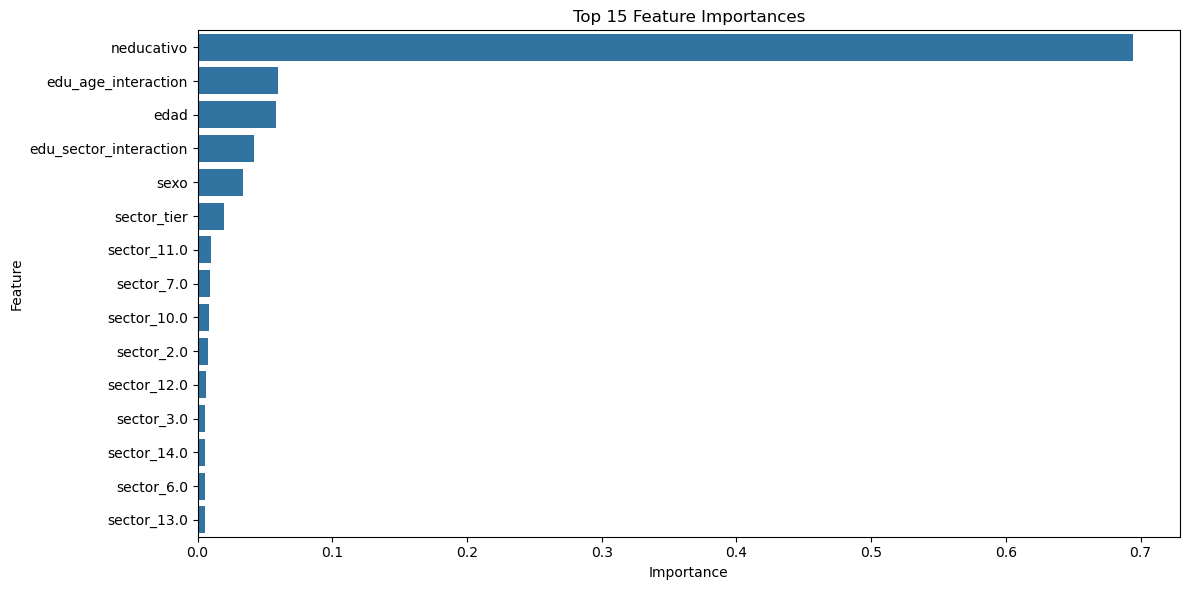

In [106]:

# Training a Random Forest to analyze feature importance
features = ['edad', 'sexo', 'neducativo', 'sector', 'sector_tier', 
           'edu_age_interaction', 'edu_sector_interaction']
X = df_clean[features]
y = df_clean['Salary_Standardized']

# Convert categorical features if needed
X = pd.get_dummies(X, columns=['sector'], drop_first=True)

# Train random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Plot feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance[:15])
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [74]:


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Test multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor()
}

# Simple evaluation function
results = {}
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    results[name] = {
        'cv_rmse': -cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    # Train on full training data
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name]['test_rmse'] = rmse
    results[name]['test_r2'] = r2

results_df = pd.DataFrame(results).T
print(results_df)

                    cv_rmse    cv_std  test_rmse   test_r2
Linear Regression  0.815143  0.004115   0.817981  0.334433
Ridge              0.815144  0.004116   0.817982  0.334431
Lasso              0.879307  0.005139   0.882309  0.225632
Random Forest      0.690648  0.002619   0.692137  0.523470
Gradient Boosting  0.740963  0.003209   0.741937  0.452430


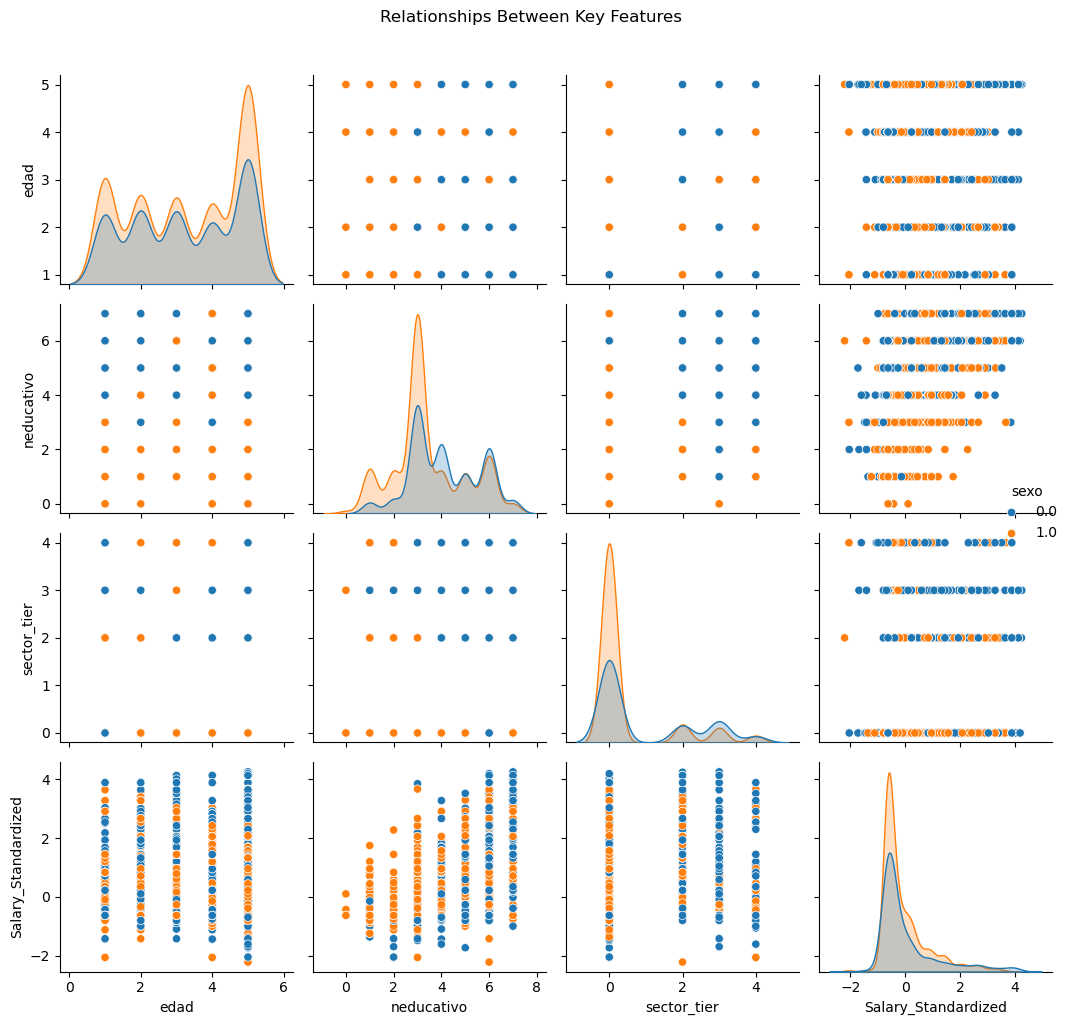

In [92]:
subset_df = df_clean[['edad', 'neducativo', 'sexo', 'sector_tier', 'Salary_Standardized']].sample(5000)
sns.pairplot(subset_df, hue='sexo')
plt.suptitle('Relationships Between Key Features', y=1.02)
plt.tight_layout()
plt.show()

<hr>
<hr>
<h2>Modelo y Evaluación</h2>

In [107]:
df_clean.head()

,edad,sexo,neducativo,salario,sector,LogSalary,Salary_MinMax,LogSalary_MinMax,Salary_Standardized,LogSalary_Standardized,edu_age_interaction,edu_sector_interaction,sector_tier
UID,,,,,,,,,,,,,
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388,9.0,9.0,0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388,9.0,9.0,0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388,9.0,9.0,0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388,9.0,9.0,0
7655976-1-2,3.0,0.0,3.0,1160000.0,3.0,13.963931,0.218868,0.901875,-0.798163,-0.89388,9.0,9.0,0


In [111]:
df_clean.drop(["LogSalary","Salary_MinMax","LogSalary_MinMax","LogSalary_Standardized"], axis=1, inplace=True)

df_clean.columns

Index(['edad', 'sexo', 'neducativo', 'salario', 'sector',
       'Salary_Standardized', 'edu_age_interaction', 'edu_sector_interaction',
       'sector_tier'],
      dtype='object')

In [124]:
X = pd.get_dummies(df_clean.drop(['salario','edu_age_interaction','edu_sector_interaction','sector_tier','Salary_Standardized'], axis=1))
y = df_clean['Salary_Standardized']
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

RandomForestRegressor(n_estimators=50, random_state=42)

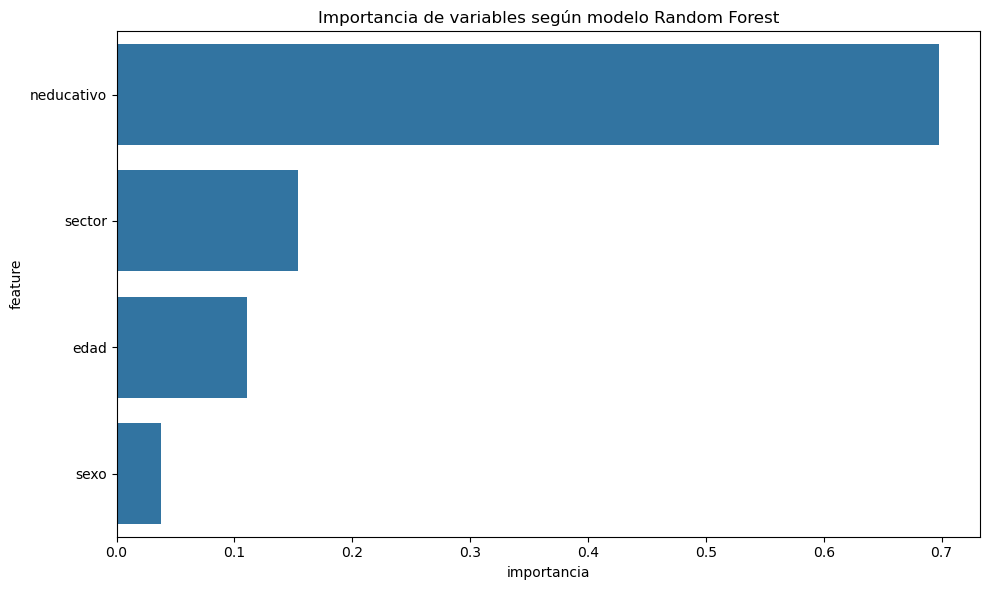

In [119]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importancia': model.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=feature_importance[:10])
plt.title('Importancia de variables según modelo Random Forest')
plt.tight_layout()

In [126]:
def evaluate_model(X, y):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create Random Forest model
    rf = RandomForestRegressor(random_state=42)
    
    # Perform cross-validation
    cv_scores = cross_val_score(rf, X_train, y_train, 
                                cv=5, 
                                scoring='neg_mean_squared_error')
    
    # Fit the model
    rf.fit(X_train, y_train)
    
    # Predictions
    y_pred = rf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("Cross-Validation Scores (Negative MSE):", -cv_scores)
    print("Mean CV Score:", -cv_scores.mean())
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2 Score:", r2)
    
    return rf

# 2. Hyperparameter Tuning with GridSearchCV
def tune_hyperparameters(X, y):
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    # Create Random Forest model
    rf = RandomForestRegressor(random_state=42)
    
    # Grid Search
    grid_search = GridSearchCV(
        estimator=rf, 
        param_grid=param_grid, 
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1  # Use all available cores
    )
    
    # Fit Grid Search
    grid_search.fit(X, y)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Cross-validated Score:", -grid_search.best_score_)
    
    return grid_search.best_estimator_




scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initial Model (with default parameters)
initial_model = RandomForestRegressor(random_state=42)
initial_model.fit(X_train, y_train)

# Initial Model Evaluation
print("\nInitial Model Evaluation:")
initial_predictions = initial_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, initial_predictions))
print("MAE:", mean_absolute_error(y_test, initial_predictions))
print("R2 Score:", r2_score(y_test, initial_predictions))

# Tune hyperparameters
tuned_model = tune_hyperparameters(X_train, y_train)

# Tuned Model Evaluation
print("\nTuned Model Evaluation:")
tuned_predictions = tuned_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, tuned_predictions))
print("MAE:", mean_absolute_error(y_test, tuned_predictions))
print("R2 Score:", r2_score(y_test, tuned_predictions))

# Compare performance
print("\nPerformance Comparison:")
print("Initial Model MSE:", mean_squared_error(y_test, initial_predictions))
print("Tuned Model MSE:", mean_squared_error(y_test, tuned_predictions))




Initial Model Evaluation:
MSE: 0.4790492007242096
MAE: 0.4570894935315836
R2 Score: 0.5234749876534648
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validated Score: 0.4770137079455984

Tuned Model Evaluation:
MSE: 0.47908582830139423
MAE: 0.4570845142832951
R2 Score: 0.5234385530729587

Performance Comparison:
Initial Model MSE: 0.4790492007242096
Tuned Model MSE: 0.47908582830139423


In [174]:
df_cleann = remove_extreme_outliers(df, column='salario', group_col='sexo', threshold=3)

df_cleann.columns

X = df_clean.drop(['salario'], axis=1)
y = df_clean['salario']

Group 0.0 (n=130098):
  - Outlier boundaries: -1,700,000.00 to 5,300,000.00
  - Identified 7488 extreme outliers (5.76%)
Group 1.0 (n=172436):
  - Outlier boundaries: -1,400,000.00 to 4,900,000.00
  - Identified 14609 extreme outliers (8.47%)

Removed total of 22097 extreme outliers
Original size: 302534, New size: 280437


In [176]:
class SalaryPredictor:
    def __init__(self, model_type=RandomForestRegressor, model_params=None):
        """
        Initialize the Salary Predictor
        
        Parameters:
        model_type (sklearn estimator): Machine learning model to use
        model_params (dict): Predefined optimal parameters
        """
        # Scalers
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        
        # Model
        self.model_type = model_type
        self.model_params = model_params or {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'random_state': 42
        }
        self.model = None
        
        # Metadata
        self.feature_columns = None
        self.original_target_mean = None
        self.original_target_std = None

    def _to_array(self, data):
        """
        Convert input to NumPy array
        """
        if isinstance(data, pd.Series):
            return data.values
        elif isinstance(data, pd.DataFrame):
            return data.values
        elif isinstance(data, np.ndarray):
            return data
        else:
            return np.array(data)

    def prepare_data(self, X, y):
        """
        Prepare and scale the data
        
        Parameters:
        X (DataFrame): Input features
        y (Series): Target variable
        
        Returns:
        tuple: Scaled features and target
        """
        # Store feature column names
        self.feature_columns = X.columns.tolist() if isinstance(X, pd.DataFrame) else None
        
        # Convert to arrays
        X_array = self._to_array(X)
        y_array = self._to_array(y)
        
        # Store original target statistics
        self.original_target_mean = np.mean(y_array)
        self.original_target_std = np.std(y_array)
        
        # Scale features
        X_scaled = self.feature_scaler.fit_transform(X_array)
        
        # Scale target variable
        y_scaled = self.target_scaler.fit_transform(y_array.reshape(-1, 1)).ravel()
        
        return X_scaled, y_scaled

    def train_model(self, X, y):
        """
        Train the model with predefined parameters
        
        Parameters:
        X (DataFrame): Input features
        y (Series): Target variable
        
        Returns:
        dict: Training results
        """
        # Prepare scaled data
        X_scaled, y_scaled = self.prepare_data(X, y)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_scaled, test_size=0.2, random_state=42
        )
        
        # Create and train model with predefined parameters
        self.model = self.model_type(**self.model_params)
        self.model.fit(X_train, y_train)
        
        # Predictions
        y_pred_scaled = self.model.predict(X_test)
        
        # Reverse scaling for evaluation
        y_test_original = (y_test * self.original_target_std) + self.original_target_mean
        y_pred_original = (y_pred_scaled * self.original_target_std) + self.original_target_mean
        
        # Evaluation metrics
        results = {
            'mse': mean_squared_error(y_test_original, y_pred_original),
            'mae': mean_absolute_error(y_test_original, y_pred_original),
            'r2': r2_score(y_test_original, y_pred_original),
            'model_params': self.model_params
        }
        
        return results

    def predict(self, X_new):
        """
        Make predictions
        
        Parameters:
        X_new (DataFrame): New input features
        
        Returns:
        numpy.ndarray: Predicted salaries
        """
        # Convert to array
        X_new_array = self._to_array(X_new)
        
        # Scale input features
        X_new_scaled = self.feature_scaler.transform(X_new_array)
        
        # Predict scaled salaries
        y_pred_scaled = self.model.predict(X_new_scaled)
        
        # Reverse scaling
        y_pred_original = (y_pred_scaled * self.original_target_std) + self.original_target_mean
        
        return y_pred_original

    def save_model(self, filepath=os.getcwd()+'/randomForest_salarios1.pkl'):
        """
        Save the entire model object
        """
        with open(filepath, 'wb') as file:
            pickle.dump(self, file)
        print(f"Model saved to {filepath}")

    @classmethod
    def load_model(cls, filepath=os.getcwd()+'/randomForest_salarios1.pkl'):
        """
        Load the entire model object
        """
        with open(filepath, 'rb') as file:
            return pickle.load(file)




# Custom model parameters (if needed)
custom_params = {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

# Create predictor with custom parameters
predictor = SalaryPredictor(model_params=custom_params)

# Train the model
training_results = predictor.train_model(X, y)
print("Training Results:")
for key, value in training_results.items():
    print(f"{key}: {value}")

# Save the model
predictor.save_model()

# Load the model
loaded_predictor = SalaryPredictor.load_model()

# Make predictions
X_sample = X.sample(n=5)
print("\n Features de prueba:\n",X_sample)
predictions = loaded_predictor.predict(X_sample)

print("\nSample Predictions:")
print(predictions)

Training Results:
mse: 321325808728.33105
mae: 374421.95425954653
r2: 0.5234465459480857
model_params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Model saved to G:\apps\jupyter\TalentoTech\proyecto/randomForest_salarios1.pkl

Sample Predictions:
[1617003.66567363 2317028.61812731 1865911.5467061  1547790.70409258
 1542547.79879069]
